<a href="https://colab.research.google.com/github/mikhael2104/Kecerdasan-Buatan/blob/main/Jobsheet_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **BAGIAN 1: KODE LATIHAN (PERCOBAAN 1, 2, & 3)**

### Percobaan 1: Support Vector Machine (SVM) (diabetes.csv)

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# 1. Load Dataset
try:
    df_diabetes = pd.read_csv('diabetes.csv')
except:
    url_diabetes = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
    cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
    df_diabetes = pd.read_csv(url_diabetes, names=cols)

# 2. Pisahkan Fitur (X) dan Target (y)
X = df_diabetes.iloc[:, :8]
y = df_diabetes['Outcome']

# 3. Standarisasi Skala Fitur (Disarankan untuk SVM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Split Data Training dan Testing (33% data uji)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.33, random_state=42)

# 5. Fit Model SVM
clf = SVC()
clf.fit(X_train, y_train)

# 6. Evaluasi Akurasi
print("Akurasi SVM Baseline:", round(clf.score(X_test, y_test) * 100, 2), "%")

Akurasi SVM Baseline: 75.59 %


### Percobaan 2: Support Vector Regression (SVR) (Salary_Data.csv)

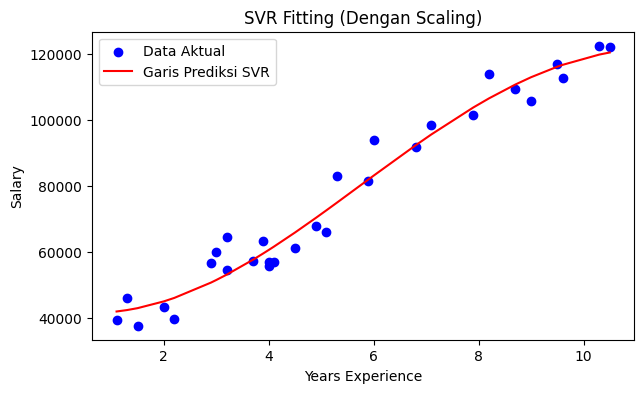

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

# 1. Load Dataset
try:
    data_salary = pd.read_csv('Salary_Data.csv')
except:
    url_salary = 'https://raw.githubusercontent.com/AbdessamadT/Salary-Prediction/main/Salary_Data.csv'
    data_salary = pd.read_csv(url_salary)

X = data_salary[['YearsExperience']].values
y = data_salary['Salary'].values

# 2. Standard Scaling untuk X dan y
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

# 3. Fit Model SVR
model_svr = SVR(C=1000, gamma=0.05, kernel='rbf')
model_svr.fit(X_scaled, y_scaled)

# 4. Visualisasi Model SVR
plt.figure(figsize=(7, 4))
plt.scatter(X, y, color='blue', label='Data Aktual')
# Inverse transform untuk mengembalikan skala prediksi ke nilai gaji semula
y_pred_scaled = model_svr.predict(X_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))

plt.plot(X, y_pred, color='red', label='Garis Prediksi SVR')
plt.title('SVR Fitting (Dengan Scaling)')
plt.xlabel('Years Experience')
plt.ylabel('Salary')
plt.legend()
plt.show()

### Percobaan 3: Naïve Bayes (iklan_sosmed.csv)

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score

# 1. Load Dataset
try:
    dataset = pd.read_csv('iklan_sosmed.csv', delimiter=';')
except:
    url_ads = 'https://raw.githubusercontent.com/tirthajyoti/Machine-Learning-with-Python/master/Datasets/Social_Network_Ads.csv'
    dataset = pd.read_csv(url_ads)

# 2. Select Columns (Age & Salary)
if 'Age' in dataset.columns:
    X = dataset[['Age', 'EstimatedSalary']].values
    y = dataset['Purchased' if 'Purchased' in dataset.columns else 'Transaksi'].values
else:
    X = dataset.iloc[:, 2:-1].values
    y = dataset.iloc[:, -1].values

# 3. Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=99)

# 4. MinMaxScaler
sc = MinMaxScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# 5. Fit Naïve Bayes
classifier = GaussianNB()
classifier.fit(X_train, y_train)

# 6. Predict & Evaluation
y_pred = classifier.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)

print(f"Akurasi Baseline Naïve Bayes : {acc * 100:.2f}%")
print("Confusion Matrix :\n", cm)

Akurasi Baseline Naïve Bayes : 87.50%
Confusion Matrix :
 [[52  4]
 [ 6 18]]


# **BAGIAN 2: TUGAS PRAKTIKUM (TUNING HYPERPARAMETER / GRID SEARCH)**

Akurasi Tuned SVM: 75.59 %
Best Params SVM  : {'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}
Best R2 Score SVR: 0.9547
Best Params SVR  : {'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}


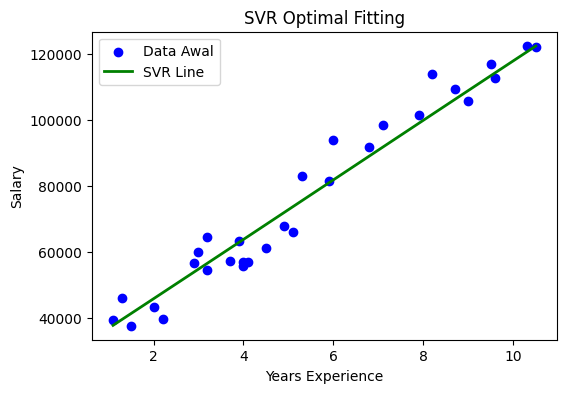

Akurasi Tuned Naïve Bayes: 87.5 %
Best var_smoothing       : 0.008111308307896872


In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.svm import SVC, SVR
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# ==========================================
# 1. TUNING SVM (diabetes.csv)
# ==========================================
try:
    df_diabetes = pd.read_csv('diabetes.csv')
except:
    url_diabetes = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
    cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
    df_diabetes = pd.read_csv(url_diabetes, names=cols)

X_d = df_diabetes.iloc[:, :8]
y_d = df_diabetes['Outcome']

scaler_d = StandardScaler()
X_d_scaled = scaler_d.fit_transform(X_d)

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_d_scaled, y_d, test_size=0.33, random_state=42)

param_grid_svc = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'poly', 'sigmoid', 'linear']
}

grid_svc = GridSearchCV(SVC(), param_grid_svc, cv=5, scoring='accuracy')
grid_svc.fit(X_train_d, y_train_d)

print("Akurasi Tuned SVM:", round(grid_svc.best_estimator_.score(X_test_d, y_test_d) * 100, 2), "%")
print("Best Params SVM  :", grid_svc.best_params_)

# ==========================================
# 2. TUNING SVR (Salary_Data.csv)
# ==========================================
try:
    data_salary = pd.read_csv('Salary_Data.csv')
except:
    url_salary = 'https://raw.githubusercontent.com/AbdessamadT/Salary-Prediction/main/Salary_Data.csv'
    data_salary = pd.read_csv(url_salary)

X_s = data_salary[['YearsExperience']].values
y_s = data_salary['Salary'].values

scaler_Xs = StandardScaler()
scaler_ys = StandardScaler()

X_s_scaled = scaler_Xs.fit_transform(X_s)
y_s_scaled = scaler_ys.fit_transform(y_s.reshape(-1, 1)).ravel()

param_grid_svr = {
    'C': [1, 10, 100, 1000, 10000],
    'gamma': [0.001, 0.01, 0.1, 1],
    'kernel': ['rbf', 'linear', 'poly']
}

grid_svr = GridSearchCV(SVR(), param_grid_svr, cv=5, scoring='r2')
grid_svr.fit(X_s_scaled, y_s_scaled)

best_svr = grid_svr.best_estimator_
print("Best R2 Score SVR:", round(best_svr.score(X_s_scaled, y_s_scaled), 4))
print("Best Params SVR  :", grid_svr.best_params_)

plt.figure(figsize=(6, 4))
plt.scatter(X_s, y_s, color='blue', label='Data Awal')
y_pred_best = scaler_ys.inverse_transform(best_svr.predict(X_s_scaled).reshape(-1, 1))
plt.plot(X_s, y_pred_best, color='green', linewidth=2, label='SVR Line')
plt.title('SVR Optimal Fitting')
plt.xlabel('Years Experience')
plt.ylabel('Salary')
plt.legend()
plt.show()

# ==========================================
# 3. TUNING NAÏVE BAYES (iklan_sosmed.csv)
# ==========================================
try:
    dataset = pd.read_csv('iklan_sosmed.csv', delimiter=';')
except:
    url_ads = 'https://raw.githubusercontent.com/tirthajyoti/Machine-Learning-with-Python/master/Datasets/Social_Network_Ads.csv'
    dataset = pd.read_csv(url_ads)

if 'Age' in dataset.columns:
    X_nb = dataset[['Age', 'EstimatedSalary']].values
    y_nb = dataset['Purchased' if 'Purchased' in dataset.columns else 'Transaksi'].values
else:
    X_nb = dataset.iloc[:, 2:-1].values
    y_nb = dataset.iloc[:, -1].values

X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(X_nb, y_nb, test_size=0.2, random_state=99)

sc_nb = MinMaxScaler()
X_train_nb_sc = sc_nb.fit_transform(X_train_nb)
X_test_nb_sc = sc_nb.transform(X_test_nb)

param_grid_nb = {'var_smoothing': np.logspace(0, -9, num=100)}
grid_nb = GridSearchCV(GaussianNB(), param_grid_nb, cv=5, scoring='accuracy')
grid_nb.fit(X_train_nb_sc, y_train_nb)

acc_nb_tuned = accuracy_score(y_test_nb, grid_nb.best_estimator_.predict(X_test_nb_sc))
print("Akurasi Tuned Naïve Bayes:", round(acc_nb_tuned * 100, 2), "%")
print("Best var_smoothing       :", grid_nb.best_params_['var_smoothing'])